# EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering

GUNATHUNGA U.A. - 230218G

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Question 1 

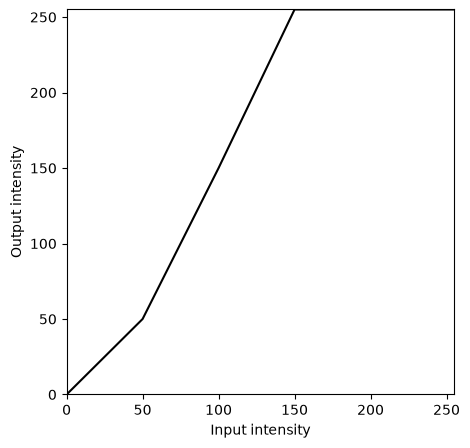

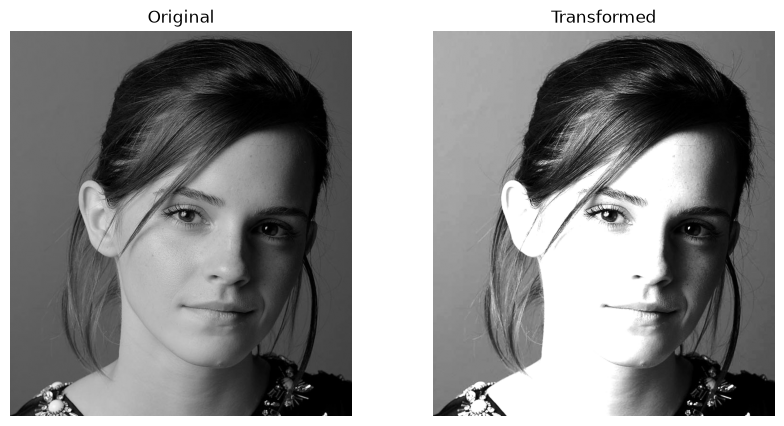

In [24]:
def intensity_transform(im, breakpoints):
    x_vals, y_vals = zip(*breakpoints)
    lut_table = np.interp(np.arange(256), x_vals, y_vals).astype(np.uint8)
    return cv2.LUT(im, lut_table)

face_input = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)
break_points = [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)]
face_output = intensity_transform(face_input, break_points)

x_plot, y_plot = zip(*break_points)
plt.figure(figsize=(5, 5))
plt.plot(x_plot, y_plot, color="black")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.show()

fig_side, axis_pair = plt.subplots(1, 2, figsize=(10, 5))
axis_pair[0].imshow(face_input, cmap="gray")
axis_pair[0].set_title("Original")
axis_pair[0].axis("off")
axis_pair[1].imshow(face_output, cmap="gray")
axis_pair[1].set_title("Transformed")
axis_pair[1].axis("off")
plt.show()

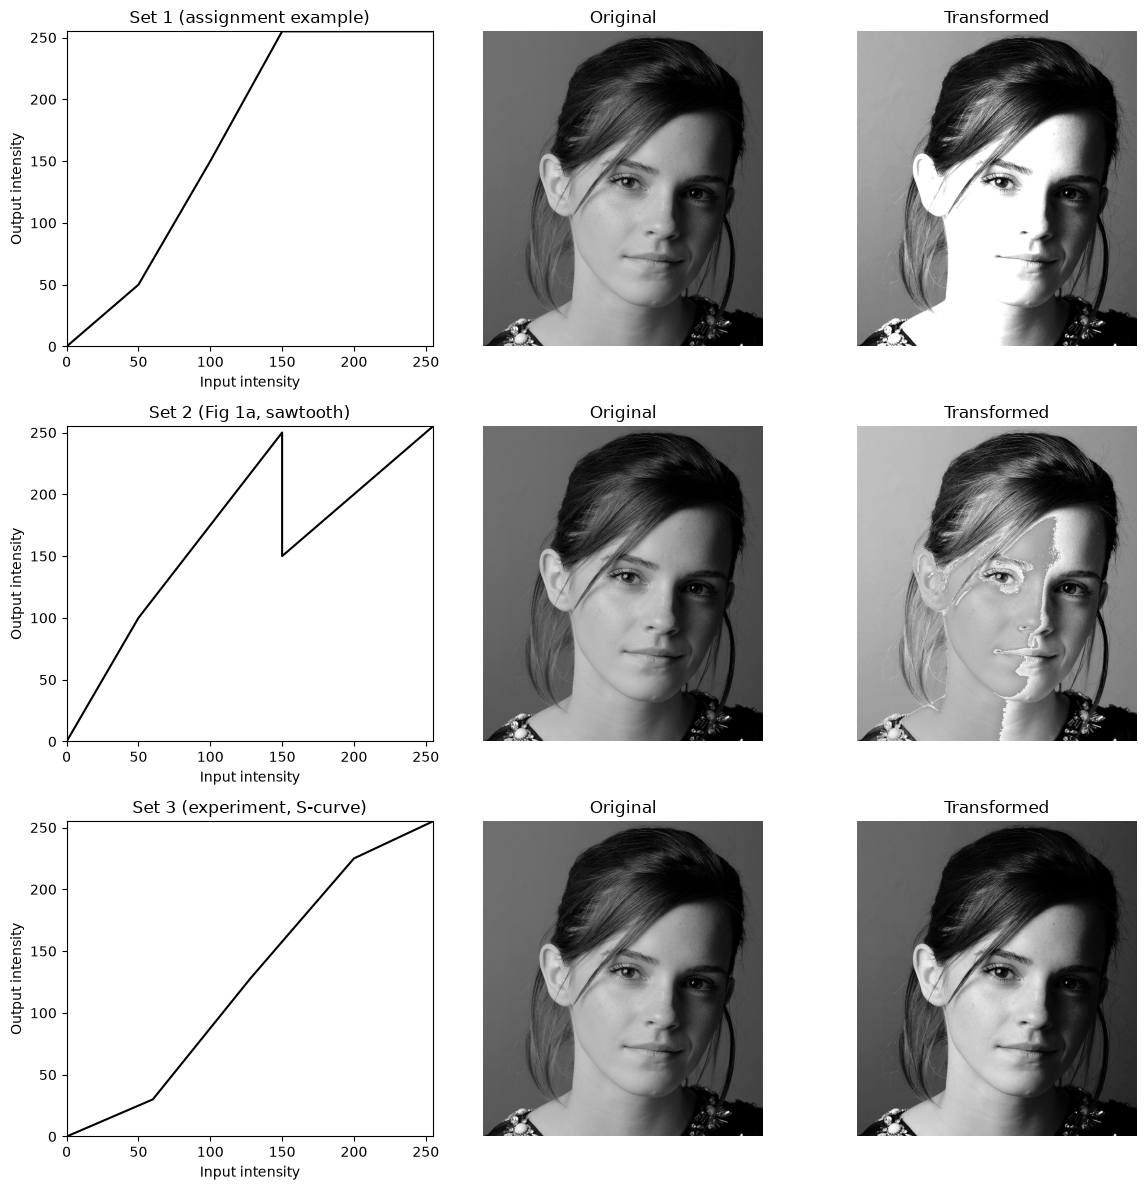

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    lut = np.zeros(256)
    for (x0, y0), (x1, y1) in zip(breakpoints, breakpoints[1:]):
        if x1 == x0:
            continue  # zero-width segment (vertical jump), skip
        idx = np.arange(x0, x1)
        lut[idx] = np.linspace(y0, y1, x1 - x0, endpoint=False)
    lut[255] = breakpoints[-1][1]
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)

face_input = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoint_sets = {
    "Set 1 (assignment example)": [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)],
    "Set 2 (Fig 1a, sawtooth)":    [(0, 0), (50, 100), (150, 250), (150, 150), (255, 255)],
    "Set 3 (experiment, S-curve)": [(0, 0), (60, 30), (128, 128), (200, 225), (255, 255)],
}

results = {}
for name, bp in breakpoint_sets.items():
    out = intensity_transform(face_input, bp)
    results[name] = (bp, out)

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
for row, (name, (bp, out)) in enumerate(results.items()):
    x_plot, y_plot = zip(*bp)
    axes[row, 0].plot(x_plot, y_plot, color="black")
    axes[row, 0].set_xlim(0, 255)
    axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_title(name)
    axes[row, 0].set_xlabel("Input intensity")
    axes[row, 0].set_ylabel("Output intensity")

    axes[row, 1].imshow(face_input, cmap="gray")
    axes[row, 1].set_title("Original")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(out, cmap="gray")
    axes[row, 2].set_title("Transformed")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Question 02


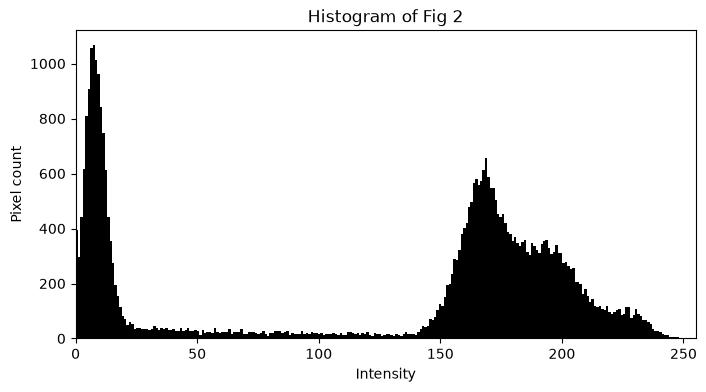

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# plain histogram to know actual pixel intensity distribution of where white and gray matter is present
plt.figure(figsize=(8, 4))
plt.hist(mri_input.ravel(), bins=256, range=(0, 255), color="black")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.title("Histogram of Fig 2")
plt.xlim(0, 255)
plt.show()

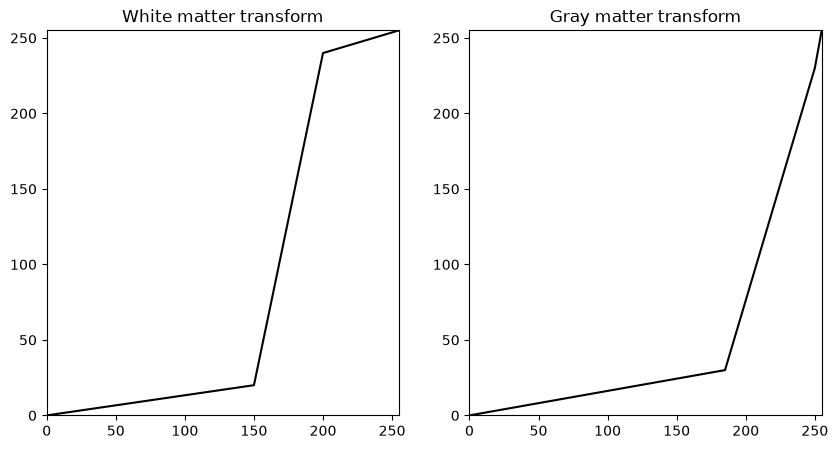

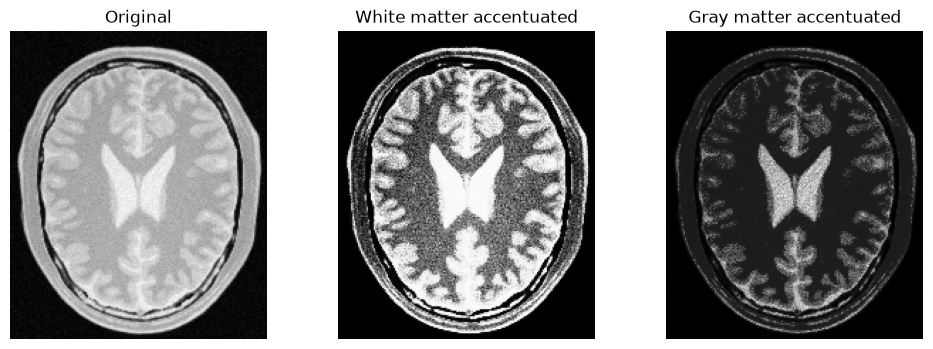

In [27]:
mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# white_breaks = [(0, 0), (150, 60), (190, 230), (255, 255)]
# gray_breaks = [(0, 0), (90, 40), (130, 220), (170, 255), (255, 255)]
white_breaks = [(0, 0), (150, 20), (200, 240), (255, 255)]
gray_breaks = [(0, 0), (185, 30), (250, 230), (255, 255)]  
white_result = intensity_transform(mri_input, white_breaks)
gray_result = intensity_transform(mri_input, gray_breaks)

x_white, y_white = zip(*white_breaks)
x_gray, y_gray = zip(*gray_breaks)

fig_curves, axis_curves = plt.subplots(1, 2, figsize=(10, 5))
axis_curves[0].plot(x_white, y_white, color="black")
axis_curves[0].set_title("White matter transform")
axis_curves[0].set_xlim(0, 255)
axis_curves[0].set_ylim(0, 255)
axis_curves[1].plot(x_gray, y_gray, color="black")
axis_curves[1].set_title("Gray matter transform")
axis_curves[1].set_xlim(0, 255)
axis_curves[1].set_ylim(0, 255)
plt.show()

fig_tissue, axis_tissue = plt.subplots(1, 3, figsize=(12, 4))
axis_tissue[0].imshow(mri_input, cmap="gray")
axis_tissue[0].set_title("Original")
axis_tissue[0].axis("off")
axis_tissue[1].imshow(white_result, cmap="gray")
axis_tissue[1].set_title("White matter accentuated")
axis_tissue[1].axis("off")
axis_tissue[2].imshow(gray_result, cmap="gray")
axis_tissue[2].set_title("Gray matter accentuated")
axis_tissue[2].axis("off")
plt.show()